# Xây dựng pipeline baseline models cho Naive Forecast và Moving Average

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [101]:
# Đọc dữ liệu từ file CSV đã được làm sạch
df = pd.read_csv("../data/processed/gold_cleaned.csv")

df.head()

,date,open,high,low,close
0,2023-04-03,1970.84,1990.64,1949.82,1984.11
1,2023-04-04,1984.59,2025.19,1977.01,2019.97
2,2023-04-05,2020.44,2032.20,2009.99,2020.35
3,2023-04-06,2020.13,2021.63,2000.88,2008.02
4,2023-04-10,2008.30,2011.17,1981.59,1989.95


In [102]:
# Kiểm tra thông tin cơ bản về dữ liệu
print("Shape:", df.shape)
print("Từ ngày:", df["date"].min())
print("Đến ngày:", df["date"].max())
print(df[["date", "close"]].head())
print(df[["date", "close"]].tail())

Shape: (775, 5)
Từ ngày: 2023-04-03
Đến ngày: 2026-04-08
         date    close
0  2023-04-03  1984.11
1  2023-04-04  2019.97
2  2023-04-05  2020.35
3  2023-04-06  2008.02
4  2023-04-10  1989.95
           date    close
770  2026-04-03  4676.42
771  2026-04-05  4610.62
772  2026-04-06  4650.89
773  2026-04-07  4833.63
774  2026-04-08  4762.18


In [103]:
# Chia dữ liệu thành tập train, validation và test dựa trên ngày
# - Train: 2023-04-03 đến 2025-03-31
# - Validation: 2025-04-01 đến 2025-09-30
# - Test: 2025-10-01 đến 2026-04-08
train_df = df[(df["date"] >= "2023-04-03") & (df["date"] <= "2025-03-31")].copy()
val_df   = df[(df["date"] >= "2025-04-01") & (df["date"] <= "2025-09-30")].copy()
test_df  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2026-04-08")].copy()

train_df["date"] = pd.to_datetime(train_df["date"])
val_df["date"] = pd.to_datetime(val_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (510, 5)
Validation shape: (130, 5)
Test shape: (135, 5)


In [104]:
# Hàm tính các chỉ số đánh giá mô hình
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

# Baseline 1: Naive Forecast
Dự báo mỗi điểm bằng giá trị close ngay trước đó

- Điểm đầu tiên của validation và test sẽ được dự báo bằng giá trị close cuối cùng của tập train
- Các điểm tiếp theo sẽ được dự báo bằng giá trị close của điểm trước đó

In [105]:
# Baseline 1: Hàm Naive Forecast
def naive_forecast(train_close, future_close):
    """
    train_close: pandas Series của tập train
    future_close: pandas Series của tập validation hoặc test
    
    Dự báo mỗi điểm bằng giá trị close của ngày trước đó.
    """
    predictions = []
    
    # Nối lịch sử train với tập cần dự báo
    history = pd.concat([train_close, future_close]).reset_index(drop=True)
    
    # Vị trí bắt đầu của tập cần dự báo trong history
    start_idx = len(train_close)
    
    for i in range(start_idx, len(history)):
        pred = history.iloc[i - 1]
        predictions.append(pred)
    
    return np.array(predictions)

In [106]:
# Chạy baseline Naive Forecast cho validation
val_naive_pred = naive_forecast(train_df["close"], val_df["close"])
val_naive_metrics = calculate_metrics(val_df["close"].values, val_naive_pred)

val_naive_metrics

{'MAE': 31.537999999999997,
 'RMSE': np.float64(40.53920554418705),
 'MAPE': np.float64(0.9408161590374817)}

In [107]:
# Chạy baseline Naive Forecast cho test
train_val_close = pd.concat([train_df["close"], val_df["close"]]).reset_index(drop=True)

test_naive_pred = naive_forecast(train_val_close, test_df["close"])
test_naive_metrics = calculate_metrics(test_df["close"].values, test_naive_pred)

test_naive_metrics

{'MAE': 64.55681481481479,
 'RMSE': np.float64(89.27880158577726),
 'MAPE': np.float64(1.4051896053030248)}

# Baseline 2: Moving Average MA(5)

dự báo mỗi điểm bằng trung bình của 5 giá trị close gần nhất trước đó

In [108]:
def moving_average_forecast(train_close, future_close, window=5):
    """
    train_close: pandas Series của tập train
    future_close: pandas Series của tập validation hoặc test
    window: số ngày trung bình trượt
    """
    predictions = []
    
    history = pd.concat([train_close, future_close]).reset_index(drop=True)
    start_idx = len(train_close)
    
    for i in range(start_idx, len(history)):
        pred = history.iloc[i - window:i].mean()
        predictions.append(pred)
    
    return np.array(predictions)

In [109]:
# Khảo sát các của sổ trung bình trượt khác nhau MA(3), Ma(5), MA(7)
ma_windows = [3, 5, 7]
ma_val_rows = []

for w in ma_windows:
    preds = moving_average_forecast(train_df["close"], val_df["close"], window=w)
    metrics = calculate_metrics(val_df["close"].values, preds)
    ma_val_rows.append({
        "Model": f"MA({w})",
        **metrics
    })

ma_window_results = pd.DataFrame(ma_val_rows).round(4)
ma_window_results


,Model,MAE,RMSE,MAPE
0,MA(3),39.1290,51.3382,1.1666
1,MA(5),47.0510,59.5188,1.4002
2,MA(7),51.9991,66.4415,1.5411


In [110]:
best_window = 3
print(f"Cửa sổ MA được chọn cho baseline chính thức: MA({best_window})")

Cửa sổ MA được chọn cho baseline chính thức: MA(3)


In [111]:
# Chạy baseline Moving Average Forecast cho validation
val_ma3_pred = moving_average_forecast(train_df["close"], val_df["close"], window=3)
val_ma3_metrics = calculate_metrics(val_df["close"].values, val_ma3_pred)

val_ma3_metrics

{'MAE': 39.12902564102564,
 'RMSE': np.float64(51.33817152191607),
 'MAPE': np.float64(1.1665968115850245)}

In [112]:
# Chạy baseline Moving Average Forecast cho test
train_val_close = pd.concat([train_df["close"], val_df["close"]]).reset_index(drop=True)

test_ma3_pred = moving_average_forecast(train_val_close, test_df["close"], window=3)
test_ma3_metrics = calculate_metrics(test_df["close"].values, test_ma3_pred)

test_ma3_metrics

{'MAE': 79.49876543209874,
 'RMSE': np.float64(105.17838535167377),
 'MAPE': np.float64(1.7445898551386725)}

# Đánh giá các baseline models và vẽ mô hình trực quan

In [124]:
# Tổng hợp kết quả đánh giá các baseline models trên tập validation
print(f"Bảng đánh giá các baseline model trên tập validation")
val_results = pd.DataFrame([
    {"Model": "Naive Forecast", **val_naive_metrics},
    {"Model": "Moving Average (3)", **val_ma3_metrics},
]).round(4)

val_results

Bảng đánh giá các baseline model trên tập validation


,Model,MAE,RMSE,MAPE
0,Naive Forecast,31.538,40.5392,0.9408
1,Moving Average (3),39.129,51.3382,1.1666


In [125]:
# Tổng hợp kết quả đánh giá các baseline models trên tập test
print(f"Bảng đánh giá các baseline model trên tập test")
test_results = pd.DataFrame([
    {"Model": "Naive Forecast", **test_naive_metrics},
    {"Model": "Moving Average (3)", **test_ma3_metrics},
]).round(4)

test_results

Bảng đánh giá các baseline model trên tập test


,Model,MAE,RMSE,MAPE
0,Naive Forecast,64.5568,89.2788,1.4052
1,Moving Average (3),79.4988,105.1784,1.7446


In [115]:
# Hàm dùng chung để vẽ mô hình

def plot_forecast(date_series, actual, predicted_list, labels, title):
    date_series = pd.to_datetime(date_series)

    plt.figure(figsize=(12, 5))
    plt.plot(date_series, actual, label="Actual")

    for pred, label in zip(predicted_list, labels):
        plt.plot(date_series, pred, label=label)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Close Price")

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

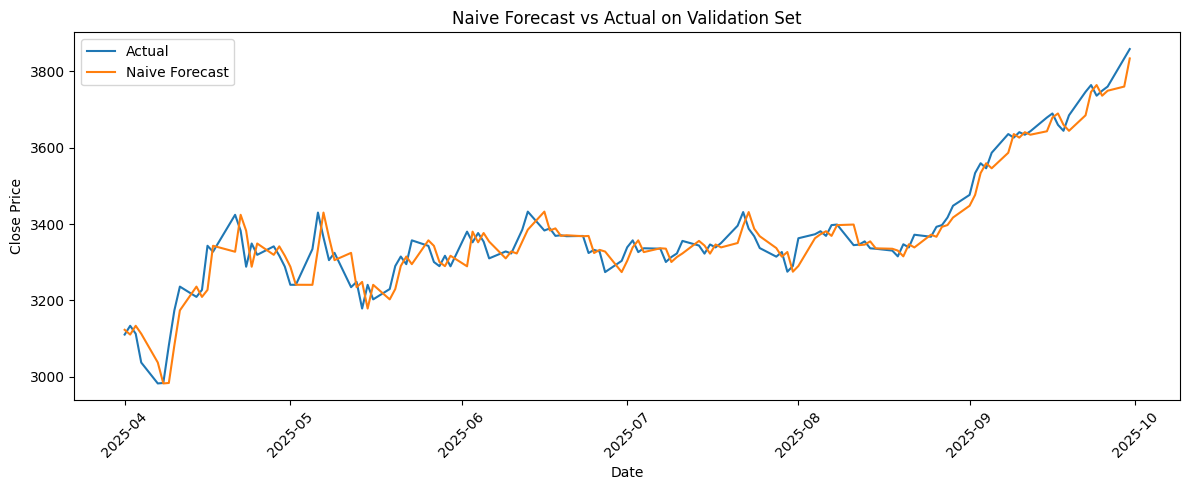

In [116]:
plot_forecast(
    val_df["date"],
    val_df["close"],
    [val_naive_pred],
    ["Naive Forecast"],
    "Naive Forecast vs Actual on Validation Set"
)

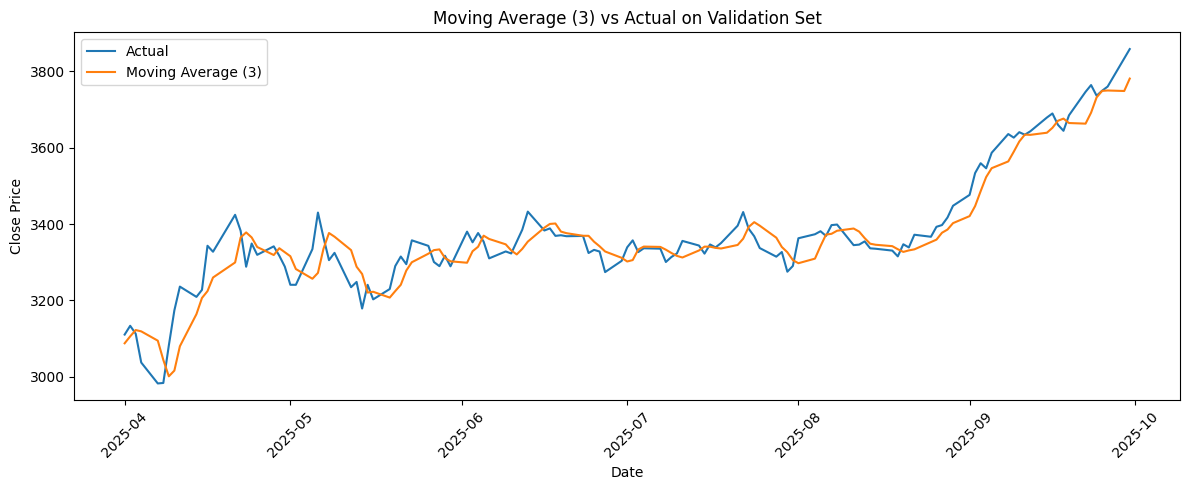

In [117]:
# Vẽ biểu đồ so sánh Moving Average (3) với giá thực tế trên tập validation
plot_forecast(
    val_df["date"],
    val_df["close"],
    [val_ma3_pred],
    ["Moving Average (3)"],
    "Moving Average (3) vs Actual on Validation Set"
)

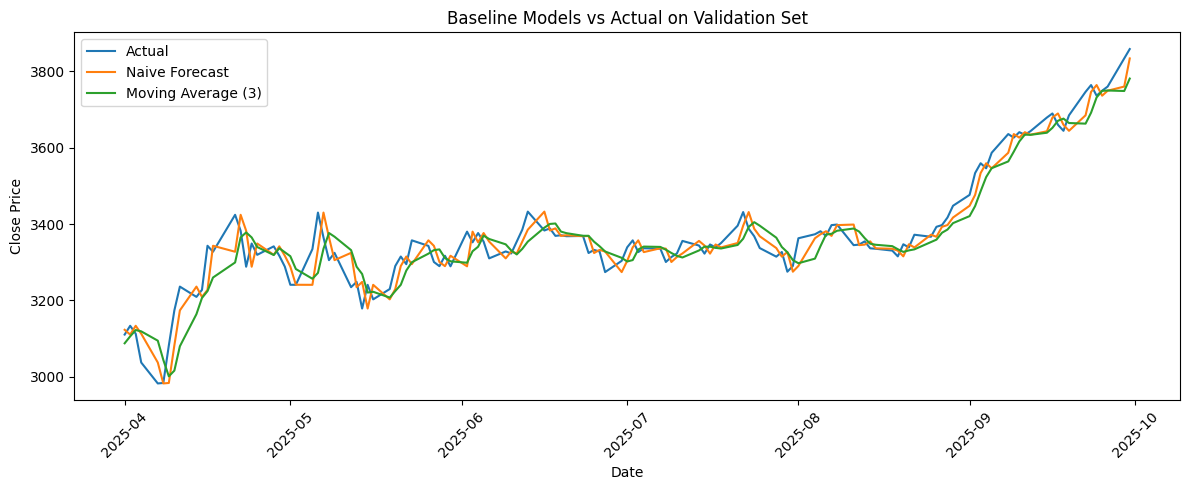

In [118]:
# Vẽ biểu đồ so sánh cả Naive Forecast và Moving Average (3) với giá thực tế trên tập validation
plot_forecast(
    val_df["date"],
    val_df["close"],
    [val_naive_pred, val_ma3_pred],
    ["Naive Forecast", "Moving Average (3)"],
    "Baseline Models vs Actual on Validation Set"
)

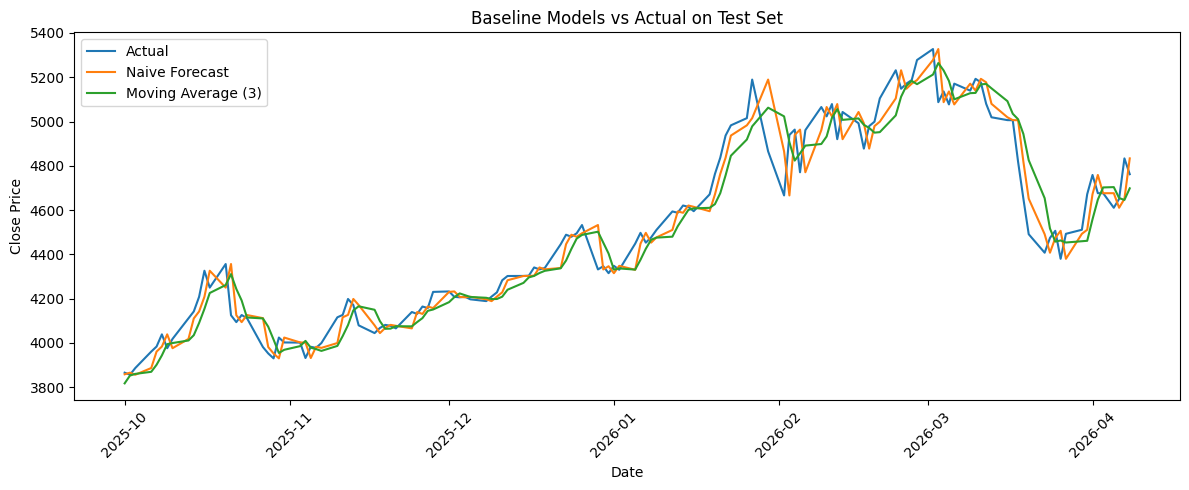

In [119]:
plot_forecast(
    test_df["date"],
    test_df["close"],
    [test_naive_pred, test_ma3_pred],
    ["Naive Forecast", "Moving Average (3)"],
    "Baseline Models vs Actual on Test Set"
)

In [120]:
val_results.to_csv("../outputs/tables/baseline_validation_results.csv", index=False)
test_results.to_csv("../outputs/tables/baseline_test_results.csv", index=False)

print("Đã lưu kết quả baseline.")

Đã lưu kết quả baseline.
